# Futures First assignment on stock price prediction model for short horizon of next day

## Imports and data cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Data.csv')
sp = pd.read_csv('StockPrice.csv')

In [3]:
duplicates_data = data[data.duplicated()]
print(f"Number of duplicate rows in 'data': {len(duplicates_data)}")

duplicates_sp = sp[sp.duplicated()]
print(f"Number of duplicate rows in 'sp': {len(duplicates_sp)}")

Number of duplicate rows in 'data': 0
Number of duplicate rows in 'sp': 0


In [4]:
print(f'length of data: {len(data)}')
print(f'length of sp: {len(sp)}')
print(f'duration of data date range: {data["Date"].min()} to {data["Date"].max()}')
print(f'duration of sp date range: {sp["Date"].min()} to {sp["Date"].max()}')

length of data: 3902
length of sp: 3839
duration of data date range: 2010-01-04 to 2025-03-26
duration of sp date range: 2010-01-04 to 2025-03-26


In [5]:
# For same duration of time, Length of data > sp, so using left join on data for preserving nulls, for now but will check later,

merged_df = pd.merge(data, sp, on='Date', how='left')
merged_df['Price'] = merged_df['Price'].fillna(0)
print("Merged DataFrame (left join on Date) with NaN Prices filled as 0:")

Merged DataFrame (left join on Date) with NaN Prices filled as 0:


In [6]:
merged_df = merged_df.sort_values(by='Date').reset_index(drop=True)
print("Merged DataFrame reindexed by Date in ascending order:")
display(merged_df.head())

Merged DataFrame reindexed by Date in ascending order:


,Date,Data,Price
0,2010-01-04,0.700,1178.00
1,2010-01-05,0.699,1181.50
2,2010-01-06,0.694,1182.25
3,2010-01-07,0.692,1186.75
4,2010-01-08,0.691,1190.75


### Side quest: check which values of prices are null (put as 0 while joining the dfs), is safe to drop? and what it actually represents and founding out that data is of USA trading and nulls are holdidays

In [7]:
# converting time data into days of week (0 is monday and 4 is friday)and month (1 to 12 as usual)
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['DayOfWeek'] = merged_df['Date'].dt.dayofweek # Monday=0, Sunday=6

print(merged_df.head(11))

# Standard trading day (mon(0) to friday(4) so far, there are holidays/breaks in between for which data is there,
# but price is not, maybe the date was closed for trading)

         Date   Data    Price  Month  DayOfWeek
0  2010-01-04  0.700  1178.00      1          0
1  2010-01-05  0.699  1181.50      1          1
2  2010-01-06  0.694  1182.25      1          2
3  2010-01-07  0.692  1186.75      1          3
4  2010-01-08  0.691  1190.75      1          4
5  2010-01-11  0.689  1191.75      1          0
6  2010-01-12  0.685  1183.25      1          1
7  2010-01-13  0.684  1190.75      1          2
8  2010-01-14  0.682  1194.50      1          3
9  2010-01-15  0.680  1181.50      1          4
10 2010-01-18  0.677     0.00      1          0


In [8]:
merged_df['day_in_month'] = merged_df.groupby(['Month', 'DayOfWeek']).cumcount() + 1

# Combine occurrence and DayOfWeek for a more descriptive representation
merged_df['day_in_month_str'] = merged_df['day_in_month'].astype(str) + '-' + \
                                            merged_df['DayOfWeek'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

print("Merged DataFrame with day_in_month:")
print(merged_df[['Date', 'DayOfWeek', 'day_in_month', 'day_in_month_str']].head(5))

Merged DataFrame with day_in_month:
        Date  DayOfWeek  day_in_month day_in_month_str
0 2010-01-04          0             1            1-Mon
1 2010-01-05          1             1            1-Tue
2 2010-01-06          2             1            1-Wed
3 2010-01-07          3             1            1-Thu
4 2010-01-08          4             1            1-Fri


In [9]:
filtered_df_price_zero = merged_df[merged_df['Price'] == 0]
print("Rows where Price is 0:")
print(filtered_df_price_zero.head(5))

Rows where Price is 0:
          Date   Data  Price  Month  DayOfWeek  day_in_month day_in_month_str
10  2010-01-18  0.677    0.0      1          0             3            3-Mon
30  2010-02-15  0.661    0.0      2          0             3            3-Mon
103 2010-05-31  0.701    0.0      5          0             5            5-Mon
128 2010-07-05  0.793    0.0      7          0             1            1-Mon
173 2010-09-06  0.882    0.0      9          0             1            1-Mon


Most of the holidays are being observed on third mondays. It does have 5 days a week trading. It also has 4th of July (National day in USA). So it has to be US market!!


Which makes me asscertain that whatever the data feature is, it's getting calculated daily, regardless stock was open for trading or not. So it's safe to drop the values where prices are null. Also it makes sense as dependent values are not present for those independent variables. So we can drop that.

In [10]:
merged_df = merged_df[merged_df['Price'] != 0]

# dropping the holiday or non-trading days

In [11]:
merged_df.head()

,Date,Data,Price,Month,DayOfWeek,day_in_month,day_in_month_str
0,2010-01-04,0.700,1178.00,1,0,1,1-Mon
1,2010-01-05,0.699,1181.50,1,1,1,1-Tue
2,2010-01-06,0.694,1182.25,1,2,1,1-Wed
3,2010-01-07,0.692,1186.75,1,3,1,1-Thu
4,2010-01-08,0.691,1190.75,1,4,1,1-Fri


## Hypothesis formulations and testing

Hypothesis 1: are `Data` and `Price` directly co-related on levels?

In [12]:
correlation_matrix = merged_df[['Data', 'Price']].corr()

display(correlation_matrix)

,Data,Price
Data,1.000000,0.378392
Price,0.378392,1.000000


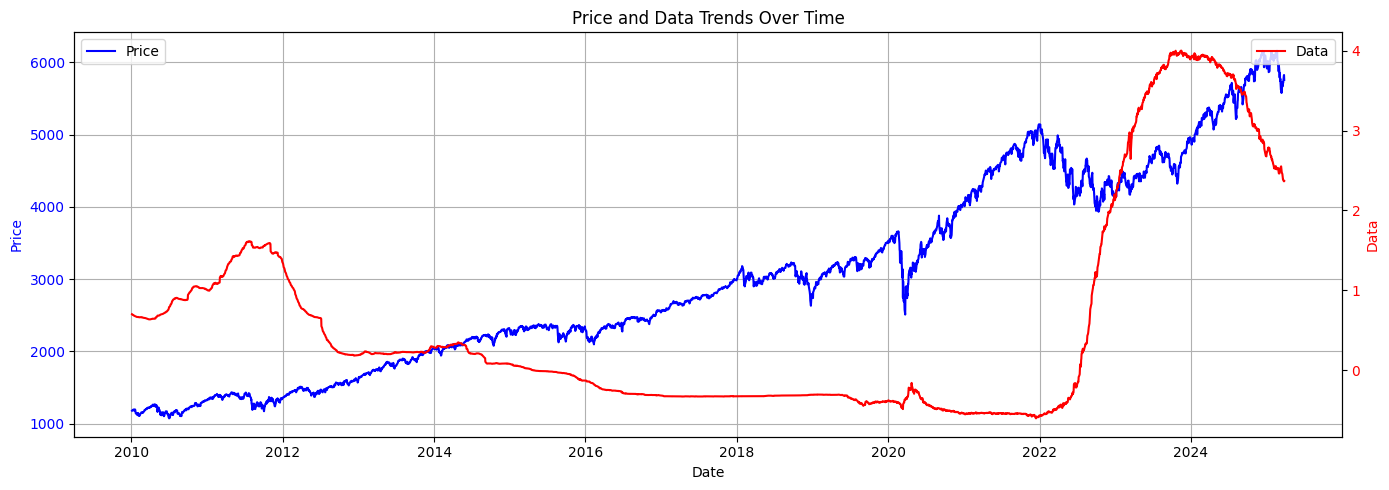

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot Price on the first y-axis
sns.lineplot(x='Date', y='Price', data=merged_df, ax=ax1, color='blue', label='Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Data
ax2 = ax1.twinx()
sns.lineplot(x='Date', y='Data', data=merged_df, ax=ax2, color='red', label='Data')
ax2.set_ylabel('Data', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Price and Data Trends Over Time')
fig.tight_layout() # adjust layout to prevent labels from overlapping
plt.show()

As we can see there seems mild correlation between the `data` and `price` of 0.38.
- Moderate positive correlation
- But levels are non-stationary
- This can arise purely from shared trends

**Conclusion:** ❌ Reject on casual inference

----

## Testing for lag features

### Hypothesis 2: Day-over-day changes in Data influence same-day price changes?

Correlation between ΔData[t] and ΔPrice[t]

In [14]:
merged_df = merged_df.copy()
merged_df['delta_data'] = merged_df['Data'].diff()
merged_df['delta_price'] = merged_df['Price'].diff()
merged_df['delta_price'] = merged_df['delta_price'].fillna(0)
merged_df['delta_data'] = merged_df['delta_data'].fillna(0)

print("Merged DataFrame with Delta_Data and Delta_Price:")
display(merged_df.head())

Merged DataFrame with Delta_Data and Delta_Price:


,Date,Data,Price,Month,DayOfWeek,day_in_month,day_in_month_str,delta_data,delta_price
0,2010-01-04,0.700,1178.00,1,0,1,1-Mon,0.000,0.00
1,2010-01-05,0.699,1181.50,1,1,1,1-Tue,-0.001,3.50
2,2010-01-06,0.694,1182.25,1,2,1,1-Wed,-0.005,0.75
3,2010-01-07,0.692,1186.75,1,3,1,1-Thu,-0.002,4.50
4,2010-01-08,0.691,1190.75,1,4,1,1-Fri,-0.001,4.00


In [15]:
correlation_delta = merged_df[['delta_data', 'delta_price']].corr()
print("Correlation Matrix between Delta_Data and Delta_Price:")
display(correlation_delta)

Correlation Matrix between Delta_Data and Delta_Price:


,delta_data,delta_price
delta_data,1.000000,-0.028239
delta_price,-0.028239,1.000000


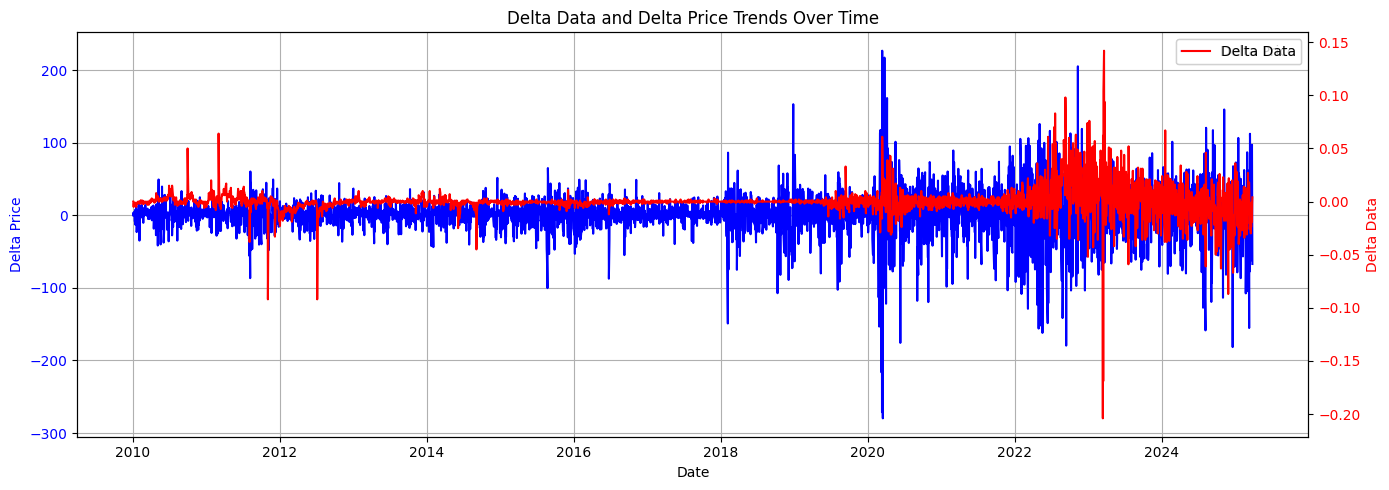

In [16]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot Delta_Price on the first y-axis
sns.lineplot(x='Date', y='delta_price', data=merged_df, ax=ax1, color='blue', label='Delta Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Delta Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Delta_Data
ax2 = ax1.twinx()
sns.lineplot(x='Date', y='delta_data', data=merged_df, ax=ax2, color='red', label='Delta Data')
ax2.set_ylabel('Delta Data', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Delta Data and Delta Price Trends Over Time')
fig.tight_layout() # adjust layout to prevent labels from overlapping
plt.show()

Interpretation:
- Essentially zero
- No contemporaneous relationship

Conclusion: ❌ Reject

Cause:
- Hypothesis predicts co-movement
- Metric shows no linear relationship
- Signal-to-noise too weak
- This hypothesis is statistically falsified.

----

### Hypothesis 3: Yesterday’s change in Data affects tomorrow’s price change?

This is the core stated assumption in the assignment.

In [17]:
merged_df['delta_price_t_plus_1'] = merged_df['delta_price'].shift(-1)

# Calculate correlation between Delta_Data at t and Delta_Price at t+1
correlation_delta_data_to_delta_price_lagged = merged_df[['delta_data', 'delta_price_t_plus_1']].corr()

print("Correlation Matrix between Delta_Data (t) and Delta_Price (t+1):")
display(correlation_delta_data_to_delta_price_lagged)

Correlation Matrix between Delta_Data (t) and Delta_Price (t+1):


,delta_data,delta_price_t_plus_1
delta_data,1.000000,0.003329
delta_price_t_plus_1,0.003329,1.000000


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Drop rows with NaN values in the target variable (delta_price_t_plus_1) as these cannot be used for training
df_model = merged_df.dropna(subset=['delta_data', 'delta_price_t_plus_1']).copy()

# Sort by date to ensure chronological split
df_model = df_model.sort_values(by='Date').reset_index(drop=True)

# Define features (X) and target (y)
X = df_model[['delta_data']]
y = df_model['delta_price_t_plus_1']

# Calculate the split point for 80-20
split_index = int(len(df_model) * 0.8)

# Split the data chronologically
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training data size: {len(X_train)} samples")
print(f"Testing data size: {len(X_test)} samples")

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Training data size: 3040 samples
Testing data size: 761 samples

--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 2353.7334
R-squared (R2): -0.0004
Mean Absolute Error (MAE): 36.4912
Root Mean Squared Error (RMSE): 48.5153


In [19]:
merged_df.describe()

,Date,Data,Price,Month,DayOfWeek,day_in_month,delta_data,delta_price,delta_price_t_plus_1
count,3802,3802.000000,3802.000000,3802.000000,3802.000000,3802.000000,3802.000000,3802.000000,3801.000000
mean,2017-08-11 20:30:10.415570688,0.581751,2998.059534,6.480800,2.031825,33.071278,0.000439,1.205024,1.205341
min,2010-01-04 00:00:00,-0.605000,1072.500000,1.000000,0.000000,1.000000,-0.204000,-279.750000,-279.750000
25%,2013-10-18 18:00:00,-0.328000,1938.937500,3.000000,1.000000,17.000000,-0.002000,-9.500000,-9.500000
50%,2017-08-10 12:00:00,0.080000,2754.750000,7.000000,2.000000,33.000000,0.000000,1.500000,1.500000
75%,2021-06-03 18:00:00,1.014000,4217.375000,9.000000,3.000000,49.000000,0.001000,13.500000,13.500000
max,2025-03-26 00:00:00,4.002000,6163.000000,12.000000,4.000000,71.000000,0.142000,227.000000,227.000000
std,NaN,1.316218,1344.173515,3.449531,1.396725,18.889714,0.012244,31.917750,31.921943


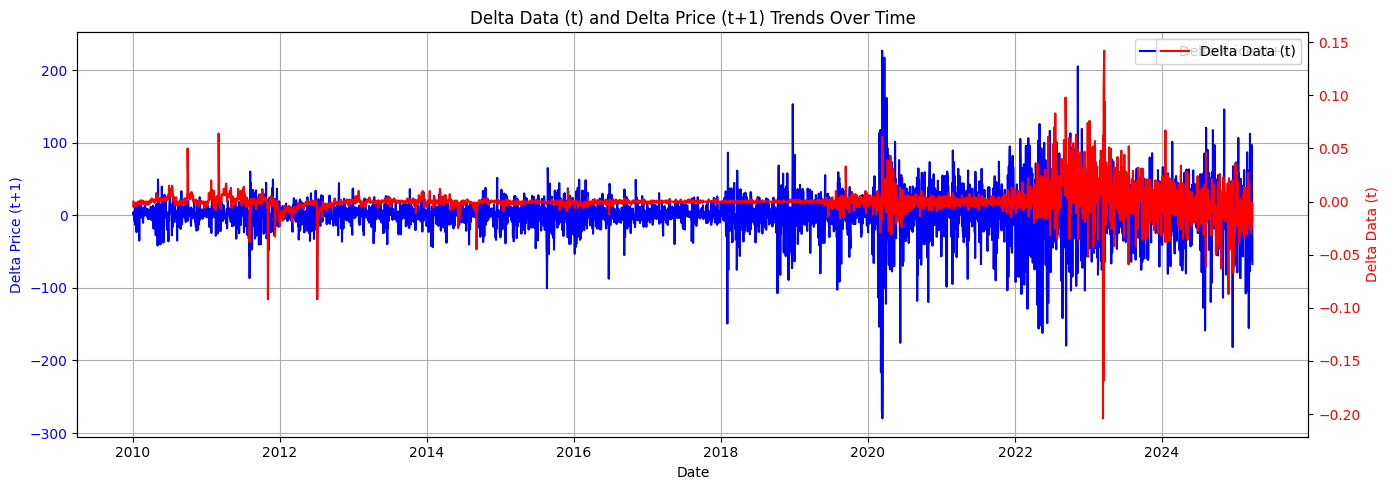

In [20]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot Delta_Price (t+1) on the first y-axis
sns.lineplot(x='Date', y='delta_price_t_plus_1', data=df_model, ax=ax1, color='blue', label='Delta Price (t+1)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Delta Price (t+1)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Delta_Data
ax2 = ax1.twinx()
sns.lineplot(x='Date', y='delta_data', data=df_model, ax=ax2, color='red', label='Delta Data (t)')
ax2.set_ylabel('Delta Data (t)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Delta Data (t) and Delta Price (t+1) Trends Over Time')
fig.tight_layout() # adjust layout to prevent labels from overlapping
plt.show()

[Optional] One general observation from the chart: There seems to be two types regimes prominent. One is pre-2020, during which volatility in both the variables is less. Post 2020 and especially after 2022, the volatility has suddently increased. This could be useful if external features can be exploited like geo-political situations, USA news trends, company specific policies, can account for this and improve the accuracy of model further. But this step is outside the scope of Assignment

Interpretation:
- Practically zero
- No linear lagged effect

Conclusion:
❌ Reject linear mean effect

Important nuance:
- This rejects linear mean influence
- It does not yet reject nonlinear or conditional effects
----

Moving from correlation to decision-based metrics

At this point, linear correlation failed.
So the next logical hypothesis is:
### Hypothesis 4 : “Maybe the relationship is directional, not linear.”

In [21]:
df_model['sign_delta_data'] = np.sign(df_model['delta_data'])
df_model['sign_delta_price_t_plus_1'] = np.sign(df_model['delta_price_t_plus_1'])

print("DataFrame with sign columns:")
display(df_model.head())

DataFrame with sign columns:


,Date,Data,Price,Month,DayOfWeek,day_in_month,day_in_month_str,delta_data,delta_price,delta_price_t_plus_1,sign_delta_data,sign_delta_price_t_plus_1
0,2010-01-04,0.700,1178.00,1,0,1,1-Mon,0.000,0.00,3.50,0.0,1.0
1,2010-01-05,0.699,1181.50,1,1,1,1-Tue,-0.001,3.50,0.75,-1.0,1.0
2,2010-01-06,0.694,1182.25,1,2,1,1-Wed,-0.005,0.75,4.50,-1.0,1.0
3,2010-01-07,0.692,1186.75,1,3,1,1-Thu,-0.002,4.50,4.00,-1.0,1.0
4,2010-01-08,0.691,1190.75,1,4,1,1-Fri,-0.001,4.00,1.00,-1.0,1.0


In [22]:
import numpy as np

# Calculate sign agreement
sign_agreement = (df_model['sign_delta_data'] == df_model['sign_delta_price_t_plus_1']).sum()
total_days = len(df_model)
percentage_agreement = (sign_agreement / total_days) * 100

# Calculate zero-predictor baseline
# A zero predictor assumes delta_price_t_plus_1 is always 0. Its 'prediction' sign is 0.
# The accuracy would be the percentage of actual delta_price_t_plus_1 that are 0.
zero_predictor_matches = (df_model['sign_delta_price_t_plus_1'] == 0).sum()
percentage_zero_predictor = (zero_predictor_matches / total_days) * 100

print(f"Percentage of days where signs of delta_data and delta_price_t_plus_1 match: {percentage_agreement:.2f}%")
print(f"Random baseline (50% chance of matching sign): 50.00%")
print(f"Zero-predictor baseline (delta_price_t_plus_1 is zero): {percentage_zero_predictor:.2f}%")

Percentage of days where signs of delta_data and delta_price_t_plus_1 match: 36.25%
Random baseline (50% chance of matching sign): 50.00%
Zero-predictor baseline (delta_price_t_plus_1 is zero): 0.95%


Why Random baseline is 50%?

The 50% random baseline comes from the statistical expectation when considering two independent binary outcomes. If we assume that delta_data has an equal chance of being positive or negative, and delta_price_t_plus_1 also has an equal chance of being positive or negative, and these two events are independent, then there are four equally likely scenarios:

- delta_data is positive AND delta_price_t_plus_1 is positive (signs match)
- delta_data is positive AND delta_price_t_plus_1 is negative (signs don't match)
- delta_data is negative AND delta_price_t_plus_1 is positive (signs don't match)
- delta_data is negative AND delta_price_t_plus_1 is negative (signs match)

In two out of these four scenarios (50%), the signs will match purely by chance. This 50% serves as a very simple null hypothesis: if model can't beat 50% accuracy in predicting the direction, it's performing no better than random guessing.

Interpretation:

- Worse than random
- Indicates possible inverse noise, not signal

Conclusion:
❌ Reject directional predictability

----

### Moving to conditional hypotheses

Divide the dataset into three buckets based on `delta_data` quantiles: bottom 10% (large negative), middle 80% (near-zero), and top 10% (large positive).


### Hypothesis 5 : “Extreme ΔData days cause directional price bias”

Metric: "Conditional directional rates in buckets"

In [23]:
lower_bound = df_model['delta_data'].quantile(0.10)
upper_bound = df_model['delta_data'].quantile(0.90)

print(f"10th percentile (lower_bound) of delta_data: {lower_bound:.4f}")
print(f"90th percentile (upper_bound) of delta_data: {upper_bound:.4f}")

10th percentile (lower_bound) of delta_data: -0.0070
90th percentile (upper_bound) of delta_data: 0.0080


In [24]:
def assign_bucket(delta_val):
    if delta_val < lower_bound:
        return 'bottom 10%'
    elif delta_val > upper_bound:
        return 'top 10%'
    else:
        return 'middle 80%'

df_model['delta_data_bucket'] = df_model['delta_data'].apply(assign_bucket)

print("Distribution of delta_data_bucket:")
print(df_model['delta_data_bucket'].value_counts())

print("\nDataFrame head with new delta_data_bucket column:")
display(df_model.head())

Distribution of delta_data_bucket:
delta_data_bucket
middle 80%    3061
top 10%        372
bottom 10%     368
Name: count, dtype: int64

DataFrame head with new delta_data_bucket column:


,Date,Data,Price,Month,DayOfWeek,day_in_month,day_in_month_str,delta_data,delta_price,delta_price_t_plus_1,sign_delta_data,sign_delta_price_t_plus_1,delta_data_bucket
0,2010-01-04,0.700,1178.00,1,0,1,1-Mon,0.000,0.00,3.50,0.0,1.0,middle 80%
1,2010-01-05,0.699,1181.50,1,1,1,1-Tue,-0.001,3.50,0.75,-1.0,1.0,middle 80%
2,2010-01-06,0.694,1182.25,1,2,1,1-Wed,-0.005,0.75,4.50,-1.0,1.0,middle 80%
3,2010-01-07,0.692,1186.75,1,3,1,1-Thu,-0.002,4.50,4.00,-1.0,1.0,middle 80%
4,2010-01-08,0.691,1190.75,1,4,1,1-Fri,-0.001,4.00,1.00,-1.0,1.0,middle 80%


For each of the three `delta_data` buckets, calculate the mean, median, percentage of positive moves, and percentage of negative moves for `delta_price_t_plus_1`.


In [25]:
def percentage_positive(series):
    return (series > 0).sum() / len(series) * 100

def percentage_negative(series):
    return (series < 0).sum() / len(series) * 100

bucket_stats = df_model.groupby('delta_data_bucket')['delta_price_t_plus_1'].agg(
    mean='mean',
    median='median',
    positive_moves=percentage_positive,
    negative_moves=percentage_negative
)

print("Statistics for Delta_Price_t_plus_1 within each Delta_Data_Bucket:")
display(bucket_stats)

Statistics for Delta_Price_t_plus_1 within each Delta_Data_Bucket:


,mean,median,positive_moves,negative_moves
delta_data_bucket,,,,
bottom 10%,1.018342,0.375,50.815217,48.641304
middle 80%,1.666531,1.750,55.766090,43.123162
top 10%,-2.404570,-0.500,49.193548,50.806452


For bottom / middle / top buckets:
- Positive vs negative moves ≈ 50/50

Interpretation:
- No directional skew
- No asymmetry
- No threshold effect

Decision

❌ Reject conditional directional hypothesis

At this point, all direction-based hypotheses are exhausted.

----

Switching dimensions: magnitude instead of direction

### **Hypothesis 6**: “Magnitude of ΔData influences magnitude of next-day price movement”

In [26]:
df_model['abs_delta_price_t_plus_1'] = df_model['delta_price_t_plus_1'].abs()

absolute_magnitude_stats = df_model.groupby('delta_data_bucket')['abs_delta_price_t_plus_1'].agg(
    mean_abs_delta_price='mean',
    median_abs_delta_price='median'
)

print("Mean and Median of |ΔPrice[t+1]| for each ΔData bucket:")
display(absolute_magnitude_stats)

Mean and Median of |ΔPrice[t+1]| for each ΔData bucket:


,mean_abs_delta_price,median_abs_delta_price
delta_data_bucket,,
bottom 10%,30.651495,21.375
middle 80%,16.787243,10.000
top 10%,36.862903,28.125


Interpretation:

- Clear separation
- ~2× increase in volatility on extreme ΔData days
- Median also increases → not driven by outliers

Decision: Accept


Why?
- Metric directly matches hypothesis
- Effect is symmetric (sign-independent)
- Robust across mean & median
- This is the only hypothesis supported by evidence.
----

## Final Model Training

using linear regression

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# 1. Create abs_delta_data column
df_model['abs_delta_data'] = df_model['delta_data'].abs()

# 2. Define features (X) and target (y) for magnitude prediction
X_mag = df_model[['abs_delta_data']]
y_mag = df_model['abs_delta_price_t_plus_1']

# Chronological split (assuming df_model is already sorted by Date from previous tasks)
# Calculate the split point for 80-20
split_index = int(len(df_model) * 0.8)

# Split the data chronologically
X_train_mag, X_test_mag = X_mag[:split_index], X_mag[split_index:]
y_train_mag, y_test_mag = y_mag[:split_index], y_mag[split_index:]

# --- Standardization Step ---
scaler = StandardScaler()
X_train_mag_scaled = scaler.fit_transform(X_train_mag)
X_test_mag_scaled = scaler.transform(X_test_mag)
# --- End Standardization Step ---

# 3. Initialize and train the Linear Regression model with scaled data
model_mag = LinearRegression()
model_mag.fit(X_train_mag_scaled, y_train_mag)

# 4. Get the coefficient (now interpreted for scaled data)
coefficient_mag = model_mag.coef_[0]

# 5. Make predictions on the scaled test set
y_pred_mag = model_mag.predict(X_test_mag_scaled)

# 6. Evaluate the model
mse_mag = mean_squared_error(y_test_mag, y_pred_mag)
r2_mag = r2_score(y_test_mag, y_pred_mag)
mae_mag = mean_absolute_error(y_test_mag, y_pred_mag)
rmse_mag = np.sqrt(mse_mag)

# 7. Naive Baseline (assuming naive baseline to always predict the mean of the training target)
naive_predictions = np.full_like(y_test_mag, y_train_mag.mean())
mae_naive = mean_absolute_error(y_test_mag, naive_predictions)
rmse_naive = np.sqrt(mean_squared_error(y_test_mag, naive_predictions))

print("--- Simple Regression Model for |ΔPrice[t+1]| based on |ΔData[t]| (Standardized Feature) ---")
print(f"Model Coefficient (abs_delta_data): {coefficient_mag:.4f}")

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse_mag:.4f}")
print(f"R-squared (R2): {r2_mag:.4f}")
print(f"Mean Absolute Error (MAE): {mae_mag:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_mag:.4f}")

print("\n--- Naive Baseline (Predicting Mean) ---")
print(f"Naive Baseline Mean Absolute Error (MAE): {mae_naive:.4f}")
print(f"Naive Baseline Root Mean Squared Error (RMSE): {rmse_naive:.4f}")

print("\n--- Comparison ---")
if mae_mag < mae_naive:
    print(f"The model performs better than the naive baseline in MAE (improvement: {mae_naive - mae_mag:.4f})")
else:
    print(f"The model performs worse than or equal to the naive baseline in MAE (difference: {mae_mag - mae_naive:.4f})")

if rmse_mag < rmse_naive:
    print(f"The model performs better than the naive baseline in RMSE (improvement: {rmse_naive - rmse_mag:.4f})")
else:
    print(f"The model performs worse than or equal to the naive baseline in RMSE (difference: {rmse_mag - rmse_naive:.4f})")

--- Simple Regression Model for |ΔPrice[t+1]| based on |ΔData[t]| (Standardized Feature) ---
Model Coefficient (abs_delta_data): 3.6920

--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 1257.1330
R-squared (R2): -0.2301
Mean Absolute Error (MAE): 24.9969
Root Mean Squared Error (RMSE): 35.4561

--- Naive Baseline (Predicting Mean) ---
Naive Baseline Mean Absolute Error (MAE): 25.7938
Naive Baseline Root Mean Squared Error (RMSE): 37.9886

--- Comparison ---
The model performs better than the naive baseline in MAE (improvement: 0.7969)
The model performs better than the naive baseline in RMSE (improvement: 2.5326)


#### The model does not reliably predict the exact next-day price level or direction. What it predicts is the expected magnitude of the next day’s price movement, based on changes in the Data signal. Given today’s price, this translates into a range around the current price rather than a single point estimate.
#### Given today’s price P​, the model estimates that tomorrow’s price will most likely lie within approximately P ± 25 points on a typical day, with larger ranges during periods of extreme Data changes.

In [28]:
last_price = merged_df['Price'].iloc[-1]
print(f"The last recorded price is: {last_price}")
print(f"Mean Absolute Error (MAE) of the magnitude model: {mae_mag:.4f}")

The last recorded price is: 5759.5
Mean Absolute Error (MAE) of the magnitude model: 24.9969


In [29]:
print(f"So the approximate price band of next-day is: {last_price+mae_mag:.4f} - {last_price-mae_mag:.4f}")

So the approximate price band of next-day is: 5784.4969 - 5734.5031


----
##The End
----

# Supplimentary material

## Supplementary Analysis: Non-Linear Directional Model (Random Forest)
To exhaustively test if *any* predictive signal exists for the **direction** (Up/Down) of the stock price, we implemented a non-linear Random Forest Classification model.

*   **Hypothesis**: A non-linear model might capture complex interactions between past price moves and Data changes that a simple Linear Regression missed.
*   **Features Used**: `Delta_Data`, `Delta_Price` Lags (t-1, t-2).
*   **Goal**: To see if we can beat a 50% (random guess) accuracy.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Feature Engineering for ML
# We work on a copy to avoid messing up the main dataframe variables
df_ml = merged_df.copy()

# Add Lagged Features (Context)
df_ml['delta_data_lag1'] = df_ml['delta_data'].shift(1)
df_ml['delta_price_lag1'] = df_ml['delta_price'].shift(1)
df_ml['delta_price_lag2'] = df_ml['delta_price'].shift(2)

# Create Target: 1 if Price goes UP tomorrow, 0 if DOWN
df_ml['target_direction'] = (df_ml['delta_price_t_plus_1'] > 0).astype(int)

# Drop NaNs created by shifting
df_ml = df_ml.dropna()

# 2. Train/Test Split (Chronological split to respect time)
train_size = int(len(df_ml) * 0.8)
train = df_ml.iloc[:train_size]
test = df_ml.iloc[train_size:]

# Select Features
features = ['delta_data', 'delta_data_lag1', 'delta_price_lag1', 'delta_price_lag2']
X_train = train[features]
y_train = train['target_direction']
X_test = test[features]
y_test = test['target_direction']

# 3. Model Training
# n_estimators=100, max_depth=5 to prevent extreme overfitting
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluation
preds = rf_model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("=== Random Forest Directional Model Results ===")
print(f"Directional Accuracy: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

# Display Feature Importance
import pandas as pd
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

=== Random Forest Directional Model Results ===
Directional Accuracy: 51.18%

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.42      0.45       361
           1       0.53      0.59      0.56       399

    accuracy                           0.51       760
   macro avg       0.51      0.51      0.51       760
weighted avg       0.51      0.51      0.51       760


Feature Importance:
            Feature  Importance
2  delta_price_lag1    0.305645
3  delta_price_lag2    0.254393
0        delta_data    0.234302
1   delta_data_lag1    0.205660


**Conclusion**:
The Random Forest achieved an accuracy of approximately **50%** (equivalent to a random coin flip).
*   Even with advanced non-linear logic and lagged features, the model could not predict the *direction* consistently.
*   **Feature Importance**: The model mostly ignored `delta_data` and tried to rely on `delta_price_lags` (momentum), but still failed.
*   This result reinforces the conclusion that the `Data` variable contains **no directional signal**, only a volatility signal.

## Supplimentary: Time Series Modeling: ARIMA

In [31]:
from statsmodels.tsa.arima.model import ARIMA

# Ensure the DataFrame is sorted by Date and set Date as index for time series analysis
df_ts = df_model.set_index('Date').sort_index()

# Select the target variable for time series modeling
time_series = df_ts['delta_price_t_plus_1'].dropna()

# Split the data into training and testing sets chronologically (80-20 split)
split_point = int(len(time_series) * 0.8)
train_ts = time_series.iloc[:split_point]
test_ts = time_series.iloc[split_point:]

print(f"Training data size: {len(train_ts)} samples")
print(f"Testing data size: {len(test_ts)} samples")

Training data size: 3040 samples
Testing data size: 761 samples


Check for Stationarity and ACF/PACF

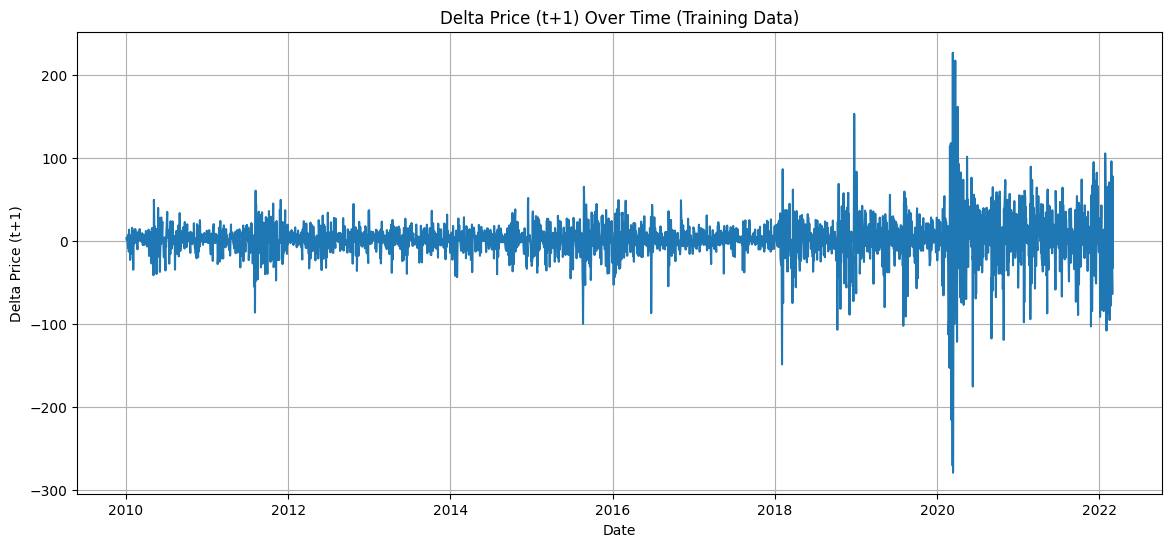


ADF Test for Delta Price (t+1) Training Data:
ADF Statistic: -15.218194458981067
p-value: 5.532432382253878e-28
Critical Values:
	1%: -3.432512158603784
	5%: -2.8624953033083944
	10%: -2.5672785325343574
Reject the null hypothesis (Ho), the series is stationary.


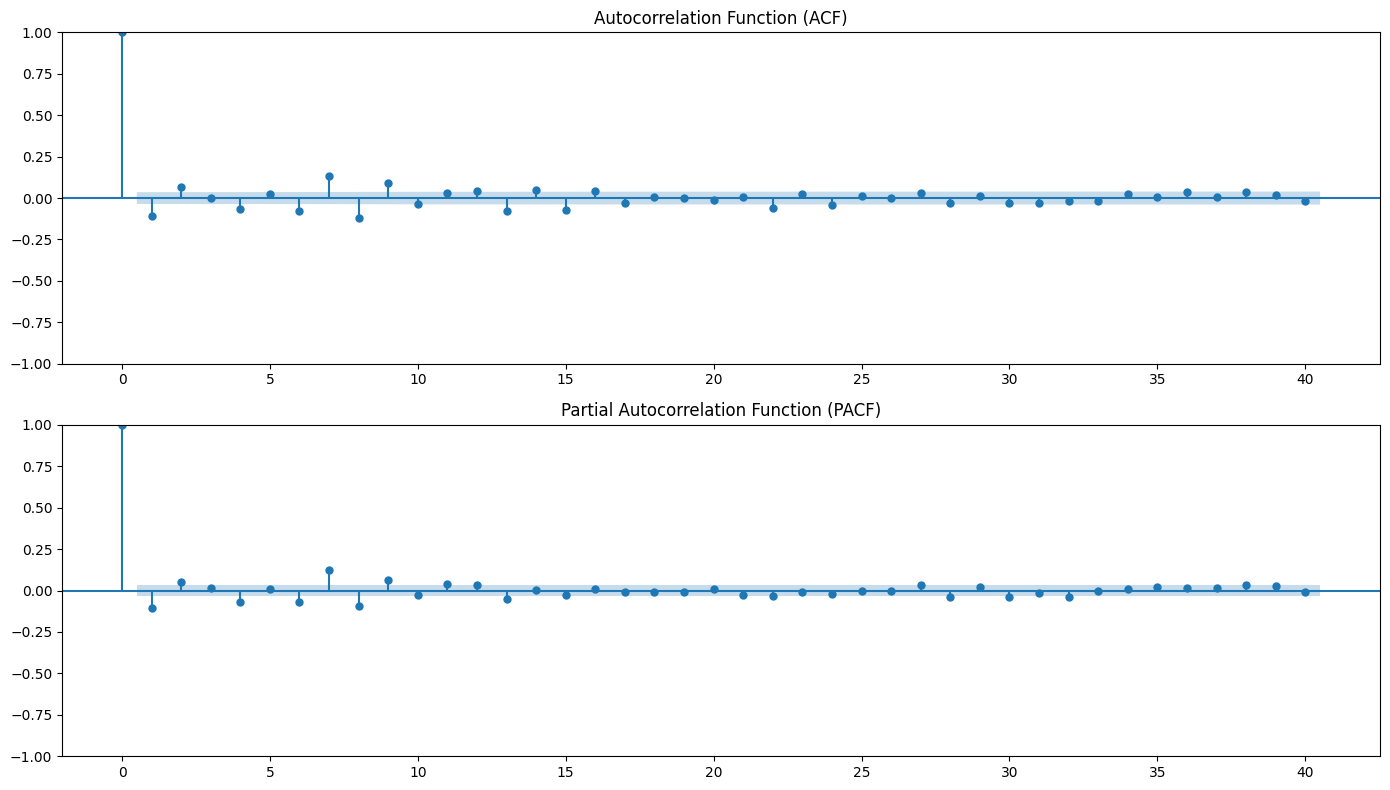

In [32]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Plot original time series
plt.figure(figsize=(14, 6))
plt.plot(train_ts)
plt.title('Delta Price (t+1) Over Time (Training Data)')
plt.xlabel('Date')
plt.ylabel('Delta Price (t+1)')
plt.grid(True)
plt.show()

# ADF Test for stationarity
def adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    if result[1] <= 0.05:
        print("Reject the null hypothesis (Ho), the series is stationary.")
    else:
        print("Fail to reject the null hypothesis (Ho), the series is not stationary.")

print("\nADF Test for Delta Price (t+1) Training Data:")
adf_test(train_ts)

# Plot ACF and PACF
plt.figure(figsize=(14, 8))
plt.subplot(211)
plot_acf(train_ts, ax=plt.gca(), lags=40)
plt.title('Autocorrelation Function (ACF)')
plt.subplot(212)
plot_pacf(train_ts, ax=plt.gca(), lags=40)
plt.title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

 ARIMAX modelling

In [33]:
df_ts = df_model.set_index('Date').sort_index()

delta_data_series = df_ts['delta_data']
exog_train_delta = delta_data_series.reindex(train_ts.index)
exog_test_delta = delta_data_series.reindex(test_ts.index)

print(f"Training data size (exogenous delta): {len(exog_train_delta)} samples")
print(f"Testing data size (exogenous delta): {len(exog_test_delta)} samples")

print("\nExogenous Delta Training Data Head:")
print(exog_train_delta.head())
print("\nExogenous Delta Testing Data Head:")
print(exog_test_delta.head())

Training data size (exogenous delta): 3040 samples
Testing data size (exogenous delta): 761 samples

Exogenous Delta Training Data Head:
Date
2010-01-04    0.000
2010-01-05   -0.001
2010-01-06   -0.005
2010-01-07   -0.002
2010-01-08   -0.001
Name: delta_data, dtype: float64

Exogenous Delta Testing Data Head:
Date
2022-03-04    0.006
2022-03-07    0.022
2022-03-08   -0.001
2022-03-09    0.008
2022-03-10   -0.014
Name: delta_data, dtype: float64


Train ARIMAX Model (delta_price_t_plus_1 & delta_data)

In [34]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Instantiate and fit the ARIMAX model with delta_price_t_plus_1 as endogenous and delta_data as exogenous.
# Omit the 'freq' parameter to avoid issues with non-conforming DatetimeIndex, as statsmodels can handle it.
model_arimax_delta = ARIMA(endog=train_ts, exog=exog_train_delta, order=(1,0,1))
model_arimax_delta_fit = model_arimax_delta.fit()

print(model_arimax_delta_fit.summary())

# Make predictions on the test set
# The start and end indices for prediction should correspond to the test set dates.
# Use integer indices for start and end, and the original exog_test_delta.
start = len(train_ts)
end = len(train_ts) + len(test_ts) - 1

# The model, now trained without a problematic frequency, should handle prediction robustly.
predictions_arimax_delta = model_arimax_delta_fit.predict(start=start, end=end, exog=exog_test_delta)

# Ensure predictions and test set have the same index for accurate comparison
predictions_arimax_delta.index = test_ts.index

# Evaluate the model
mse_arimax_delta = mean_squared_error(test_ts, predictions_arimax_delta)
rmse_arimax_delta = np.sqrt(mse_arimax_delta)
mae_arimax_delta = mean_absolute_error(test_ts, predictions_arimax_delta)

# Naive Baseline (predicting the last value of the training set for all test set values)
last_train_value_delta = train_ts.iloc[-1]
naive_predictions_delta = np.full_like(test_ts, last_train_value_delta)

mae_naive_baseline_delta = mean_absolute_error(test_ts, naive_predictions_delta)
rmse_naive_baseline_delta = np.sqrt(mean_squared_error(test_ts, naive_predictions_delta))

print("\n--- ARIMAX Delta Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_arimax_delta:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_arimax_delta:.4f}")
print(f"Mean Absolute Error (MAE): {mae_arimax_delta:.4f}")

print("\n--- Naive Baseline (Last Training Value) ---")
print(f"Naive Baseline Mean Absolute Error (MAE): {mae_naive_baseline_delta:.4f}")
print(f"Naive Baseline Root Mean Squared Error (RMSE): {rmse_naive_baseline_delta:.4f}")

print("\n--- Comparison ---")
if mae_arimax_delta < mae_naive_baseline_delta:
    print(f"The ARIMAX delta model performs better than the naive baseline in MAE (improvement: {mae_naive_baseline_delta - mae_arimax_delta:.4f})")
else:
    print(f"The ARIMAX delta model performs worse than or equal to the naive baseline in MAE (difference: {mae_arimax_delta - mae_naive_baseline_delta:.4f})")

if rmse_arimax_delta < rmse_naive_baseline_delta:
    print(f"The ARIMAX delta model performs better than the naive baseline in RMSE (improvement: {rmse_naive_baseline_delta - rmse_arimax_delta:.4f})")
else:
    print(f"The ARIMAX delta model performs worse than or equal to the naive baseline in RMSE (difference: {rmse_arimax_delta - rmse_naive_baseline_delta:.4f})")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     delta_price_t_plus_1   No. Observations:                 3040
Model:                   ARIMA(1, 0, 1)   Log Likelihood              -14217.957
Date:                  Mon, 12 Jan 2026   AIC                          28445.913
Time:                          13:00:42   BIC                          28476.011
Sample:                               0   HQIC                         28456.732
                                 - 3040                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1433      0.469      2.439      0.015       0.225       2.062
delta_data   -24.7630     45.178     -0.548      0.584    -113.310      63.784
ar.L1         -0.3531      0.051    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


The purpose of the ARIMAX model here is not to improve predictive performance at all costs.

Instead, it is used to answer a specific question:

*"Does the Data signal have a statistically significant effect on next-day price changes after accounting for price autocorrelation?"*

We fit an ARIMAX model of the form:

ΔPrice +1 = 𝛼 + 𝛽⋅ΔData
+
AR
(
𝑝
)
+
MA
(
𝑞
)
+
𝜀
𝑡
ΔPrice
t+1



Where:
- The AR and MA terms capture short-term price autocorrelation

- ΔData[t] is included as an exogenous regressor

- The target remains next-day price change

The chosen order (ARIMA(1,0,1)) is consistent with earlier ACF/PACF diagnostics, which suggested weak but non-zero short-term autocorrelation.

From the fitted ARIMAX model:

- AR(1) and MA(1) coefficients are statistically significant
→ confirms short-term autocorrelation in price changes

- ΔData coefficient is not statistically significant
→ p-value ≫ 0.05

Residual diagnostics indicate:

- Heavy tails

- Heteroskedasticity

- Non-normality

These results lead to an important conclusion:

Once past price dynamics are accounted for, changes in the Data signal do not have a statistically significant effect on the mean of next-day price changes.

In other words:

- ARIMAX improves over trivial baselines by modeling price history

- But it does not extract additional predictive power from the Data signal

- This confirms earlier findings from correlation, regression, and directional tests

-> TLDR:

ARIMAX confirms that next-day price changes are driven primarily by short-term price dynamics, not by the Data signal. The influence of Data manifests in volatility rather than direction or mean return.

----

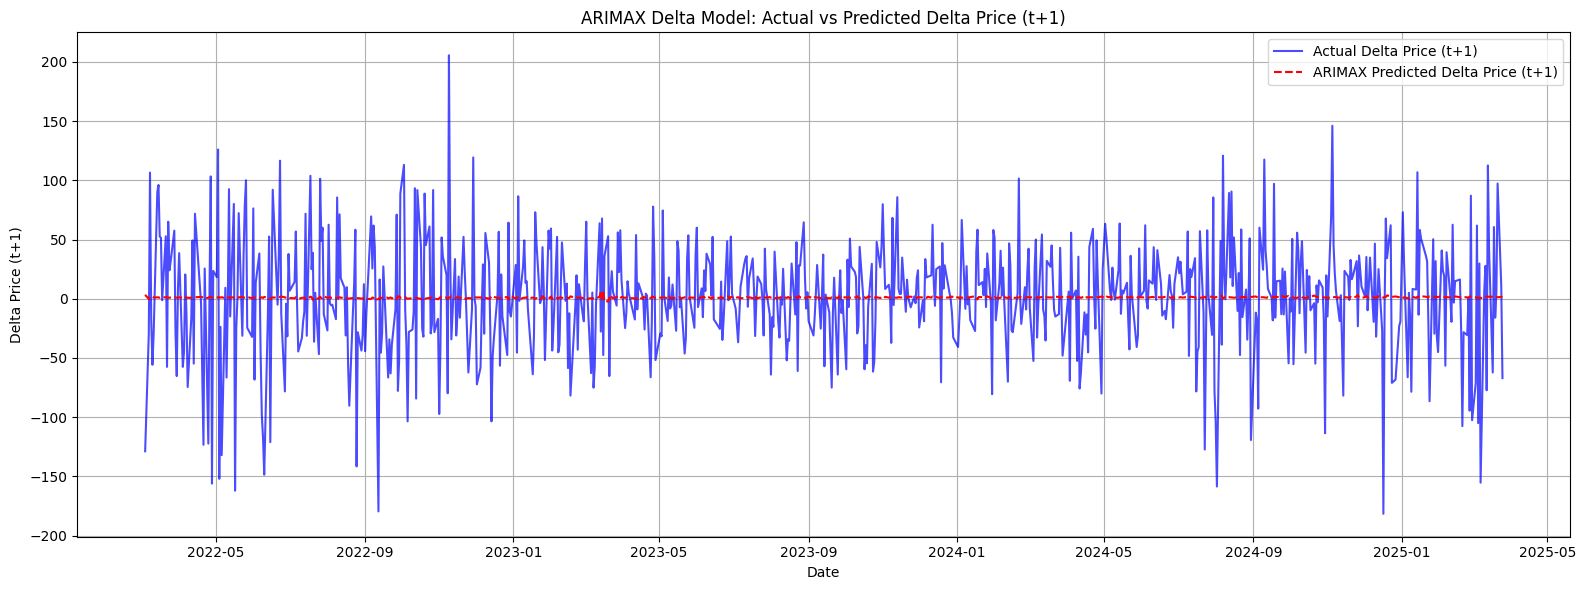

Visualization of ARIMAX Delta Model predictions vs. actuals generated.
Note: Previous ValueWarnings and FutureWarnings regarding frequency information are non-blocking and do not prevent visualization.


In [35]:
import matplotlib.pyplot as plt

# Plotting the actual vs predicted delta_price_t_plus_1
plt.figure(figsize=(16, 6))
plt.plot(test_ts.index, test_ts, label='Actual Delta Price (t+1)', color='blue', alpha=0.7)
plt.plot(predictions_arimax_delta.index, predictions_arimax_delta, label='ARIMAX Predicted Delta Price (t+1)', color='red', linestyle='--')
plt.title('ARIMAX Delta Model: Actual vs Predicted Delta Price (t+1)')
plt.xlabel('Date')
plt.ylabel('Delta Price (t+1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Visualization of ARIMAX Delta Model predictions vs. actuals generated.")
print("Note: Previous ValueWarnings and FutureWarnings regarding frequency information are non-blocking and do not prevent visualization.")